# Task 7: Compute percentile ranks

**Goal:** put the three indices on one comparable scale. They use incompatible units (Eloundou: share of
tasks in [0, 1]; AIOE: z-score; Frey-Osborne: bimodal probability), so each is converted to a
**percentile rank from 0 to 100**, where higher always means more exposed or at higher risk.

**Reads:** `data/processed/merged_ai_risk_v0.csv` and the three interim tables.
**Writes:** `data/processed/percentile_ranks_v0.csv`, used by [`package_v0.ipynb`](package_v0.ipynb). No input is modified.

**Selected rules**
- **Two ranking populations, one primary.** The main `pct_` columns rank each index among the same 693
  merged occupations, so a 50 means "the median of this table" on every index. `pct_full_` columns rank each
  index among every occupation it scores (798 / 800 / 699) and are kept for reference, because the join is
  biased (see `eda/eda_processed.ipynb`). The team can switch which one is primary without recomputing anything.
- **Ties share the average rank.** Frey-Osborne has many tied scores (e.g. 0.99); averaging keeps tied
  occupations equal instead of ordering them arbitrarily.
- **Scale:** `rank(pct=True) × 100`, i.e. the share of occupations scoring at or below this one.
- **Disagreement:** `pct_spread` = max − min of the three headline ranks (Eloundou beta GPT-4, AIOE,
  Frey-Osborne). Human-rated Eloundou beta is ranked too, as a sensitivity check.

**Not chosen:** re-standardizing to z-scores (Frey-Osborne's bimodality makes means and sds misleading),
and employment weighting (no employment counts in the project data yet).

| Column prefix | Ranked among | Use for |
|---|---|---|
| `pct_` | the 693 occupations in `merged_ai_risk_v0.csv` | comparing indices with each other (same population) |
| `pct_full_` | every occupation that index scores | an occupation's standing within its own index |

## Setup

Works in **Google Colab** and **locally**:
- **Colab:** mounts Google Drive and reads from the team folder
  `MyDrive/BTT Fall AI Studio (swytch 1b)/data/` (the same folder `Milestone_1.ipynb` uses). If the folder was
  shared with you, add a shortcut to it in *My Drive* first. Any file missing from Drive is downloaded
  from the GitHub repo instead, so the notebook still runs without Drive access.
- **Locally:** reads `data/` from the repo (run from anywhere inside the repo with the project `.venv`).

In [1]:
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/BTT Fall AI Studio (swytch 1b)")
else:
    # Repo root = nearest folder (this one or above) that contains data/, so any notebooks/ subfolder works
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir()), Path.cwd())

DATA = ROOT / "data"
# Fallback source for files not found under DATA (switch the branch to main once this is merged)
GITHUB_DATA = "https://raw.githubusercontent.com/Break-Through-Tech/Swytch-1B-do-ai-job-risk-indices-agree/kamsi/data"
print("data folder:", DATA, "(found)" if DATA.exists() else "(not found, using GitHub)")


def data_file(rel):
    """Path to data/<rel>: from Drive / the repo if present, else downloaded once from GitHub."""
    path = DATA / rel
    if path.exists():
        return path
    cached = Path(tempfile.gettempdir()) / "swytch_data" / rel
    if not cached.exists():
        cached.parent.mkdir(parents=True, exist_ok=True)
        print(f"downloading {rel} from GitHub")
        urllib.request.urlretrieve(f"{GITHUB_DATA}/{rel}", cached)
    return cached


OUT = (ROOT if ROOT.exists() else Path.cwd()) / "notebooks" / "figures"
OUT.mkdir(parents=True, exist_ok=True)

MAJOR_GROUPS = {
    "11": "Management", "13": "Business & Financial", "15": "Computer & Mathematical",
    "17": "Architecture & Engineering", "19": "Life, Physical & Social Sci.",
    "21": "Community & Social Service", "23": "Legal", "25": "Education & Library",
    "27": "Arts, Design & Media", "29": "Healthcare Practitioners", "31": "Healthcare Support",
    "33": "Protective Service", "35": "Food Preparation & Serving", "37": "Building & Grounds",
    "39": "Personal Care & Service", "41": "Sales", "43": "Office & Admin Support",
    "45": "Farming, Fishing & Forestry", "47": "Construction & Extraction",
    "49": "Installation & Repair", "51": "Production", "53": "Transportation & Material Moving",
    "55": "Military",
}


def boxplot_by_group(df, code_col, value_col, title):
    """Horizontal boxplot of value_col per SOC major group, sorted by median."""
    groups = df.assign(mg=df[code_col].str[:2]).groupby("mg")[value_col]
    order = groups.median().sort_values().index
    data = [groups.get_group(g) for g in order]
    fig, ax = plt.subplots(figsize=(8, 7))
    try:
        ax.boxplot(data, orientation="horizontal")  # matplotlib >= 3.10
    except TypeError:
        ax.boxplot(data, vert=False)
    ax.set_yticks(range(1, len(order) + 1), [f"{g} {MAJOR_GROUPS[g]}" for g in order])
    ax.set_xlabel(value_col)
    ax.set_title(title, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def load_crosswalk():
    """BLS SOC 2010 -> 2018 crosswalk with short column names."""
    cw = pd.read_excel(data_file("raw/soc_2010_to_2018_crosswalk.xlsx"), header=8, dtype=str)
    cw.columns = ["soc10", "title10", "soc18", "title18"]
    return cw.apply(lambda s: s.str.strip())

data folder: C:\Users\Kamsi\Downloads\code\Swytch-1B-do-ai-job-risk-indices-agree\data (found)


## 1. Inputs

In [2]:
INDICES = {  # output name -> (source column, interim file, code column)
    "eloundou_beta": ("dv_rating_beta", "interim/eloundou_soc6.csv", "soc6"),
    "eloundou_beta_human": ("human_rating_beta", "interim/eloundou_soc6.csv", "soc6"),
    "aioe": ("AIOE", "interim/aioe_soc2018.csv", "soc2018"),
    "frey_osborne": ("probability", "interim/frey_osborne_soc2018.csv", "soc2018"),
}

merged = pd.read_csv(data_file("processed/merged_ai_risk_v0.csv"))
full = {name: pd.read_csv(data_file(path)).rename(columns={key: "soc"})[["soc", col]]
        for name, (col, path, key) in INDICES.items()}
print("merged rows:", len(merged))
for name, df in full.items():
    print(f"{name:<20} full rows: {len(df)}")

merged rows: 693
eloundou_beta        full rows: 798
eloundou_beta_human  full rows: 798
aioe                 full rows: 800
frey_osborne         full rows: 699


## 2. Compute percentile ranks

`rank(pct=True)` gives each occupation the share of occupations with a score at or below its own;
tied scores share the average rank (Frey-Osborne has many ties, e.g. 0.99). Multiplied by 100.

In [3]:
def percentile(s):
    return s.rank(method="average", pct=True) * 100


ranks = merged[["soc"]].copy()
for name, (col, _, _) in INDICES.items():
    ranks[f"pct_{name}"] = percentile(merged[col])

for name, (col, _, _) in INDICES.items():
    df = full[name].assign(**{f"pct_full_{name}": lambda d: percentile(d[col])})
    ranks = ranks.merge(df[["soc", f"pct_full_{name}"]], on="soc", how="left")

# Disagreement between the three indices (headline: GPT-4 Eloundou beta, AIOE, Frey-Osborne)
headline = ["pct_eloundou_beta", "pct_aioe", "pct_frey_osborne"]
ranks["pct_spread"] = ranks[headline].max(axis=1) - ranks[headline].min(axis=1)
ranks.head()

,soc,pct_eloundou_beta,pct_eloundou_beta_human,pct_aioe,pct_frey_osborne,pct_full_eloundou_beta,pct_full_eloundou_beta_human,pct_full_aioe,pct_full_frey_osborne,pct_spread
0,11-1011,79.797980,65.656566,92.063492,9.740260,79.323308,63.283208,91.000,9.656652,82.323232
1,11-1021,73.881674,67.316017,66.089466,28.138528,72.681704,65.476190,62.750,28.040057,45.743146
2,11-2011,73.304473,89.177489,89.898990,17.965368,71.679198,88.471178,87.625,17.954220,71.933622
3,11-2021,78.066378,91.630592,90.909091,8.730159,77.506266,91.102757,88.875,8.655222,82.178932
4,11-2022,69.696970,80.230880,87.445887,8.152958,67.293233,79.573935,85.250,8.082976,79.292929


## 3. Checks

In [4]:
pct_cols = [c for c in ranks.columns if c.startswith("pct_") and c != "pct_spread"]
assert len(ranks) == len(merged) and ranks.soc.is_unique
assert ranks[pct_cols].notna().all().all(), "every merged occupation should have every rank"
assert ranks[pct_cols].gt(0).all().all() and ranks[pct_cols].le(100).all().all()

# Ranks must preserve order: Spearman(raw, rank) = 1 within the merged table
for name, (col, _, _) in INDICES.items():
    rho = pd.concat([merged[col], ranks[f"pct_{name}"]], axis=1).corr(method="spearman").iloc[0, 1]
    print(f"{name:<20} Spearman(raw, pct) = {rho:.4f} | ties: {merged[col].duplicated().sum()}")

print(ranks[pct_cols + ["pct_spread"]].describe().round(1))

eloundou_beta        Spearman(raw, pct) = 1.0000 | ties: 242
eloundou_beta_human  Spearman(raw, pct) = 1.0000 | ties: 249
aioe                 Spearman(raw, pct) = 1.0000 | ties: 12
frey_osborne         Spearman(raw, pct) = 1.0000 | ties: 509
       pct_eloundou_beta  pct_eloundou_beta_human  pct_aioe  pct_frey_osborne  pct_full_eloundou_beta  pct_full_eloundou_beta_human  pct_full_aioe  pct_full_frey_osborne  pct_spread
count              693.0                    693.0     693.0             693.0                   693.0                         693.0          693.0                  693.0       693.0
mean                50.1                     50.1      50.1              50.1                    48.3                          48.3           47.6                   50.0        46.6
std                 28.9                     28.9      28.9              28.9                    29.3                          29.3           28.7                   28.9        22.3
min                  3.3     

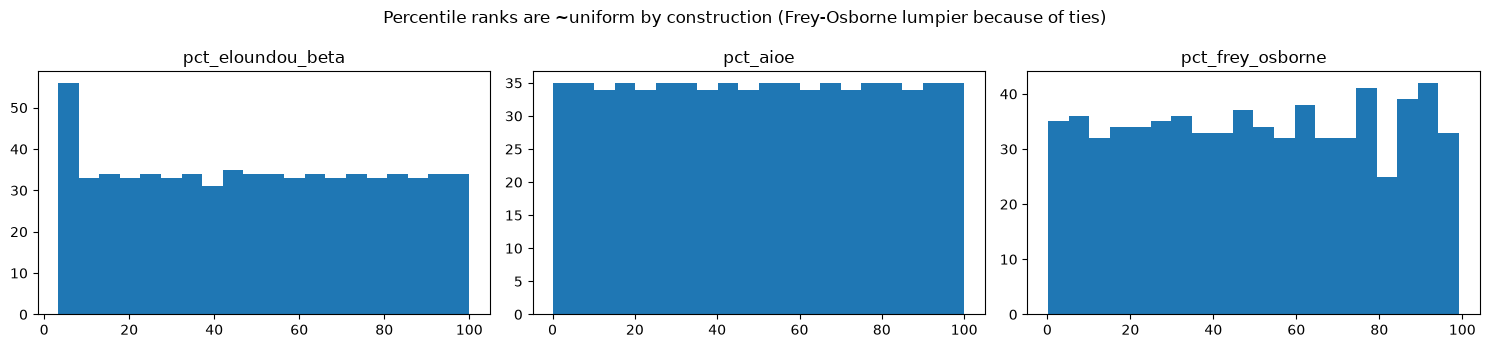

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, headline):
    ax.hist(ranks[col], bins=20)
    ax.set_title(col)
fig.suptitle("Percentile ranks are ~uniform by construction (Frey-Osborne lumpier because of ties)")
fig.tight_layout()
plt.show()

## 4. Merged-table vs. full-table ranks
How much does an occupation's rank change depending on which population it is ranked in?

eloundou_beta        mean shift:  +1.8 | mean |shift|:  1.9 | max |shift|:  4.2
eloundou_beta_human  mean shift:  +1.8 | mean |shift|:  1.8 | max |shift|:  3.7
aioe                 mean shift:  +2.5 | mean |shift|:  2.5 | max |shift|:  4.9
frey_osborne         mean shift:  +0.1 | mean |shift|:  0.1 | max |shift|:  0.2


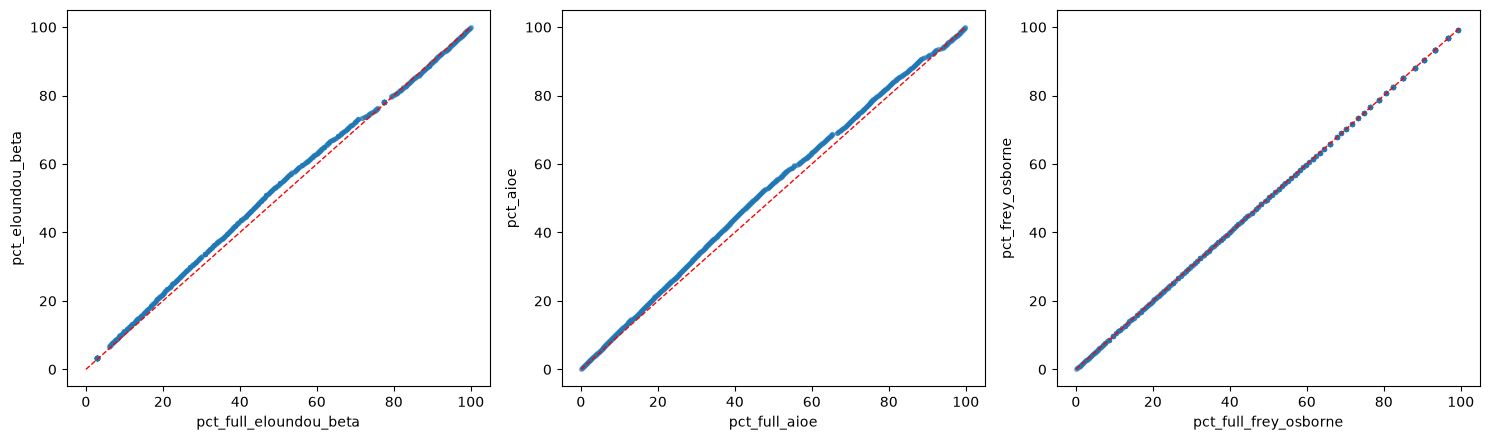

In [6]:
for name in INDICES:
    d = ranks[f"pct_{name}"] - ranks[f"pct_full_{name}"]
    print(f"{name:<20} mean shift: {d.mean():+5.1f} | mean |shift|: {d.abs().mean():4.1f} | max |shift|: {d.abs().max():4.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, ["eloundou_beta", "aioe", "frey_osborne"]):
    ax.scatter(ranks[f"pct_full_{name}"], ranks[f"pct_{name}"], s=8, alpha=0.4)
    ax.plot([0, 100], [0, 100], "r--", linewidth=1)
    ax.set_xlabel(f"pct_full_{name}")
    ax.set_ylabel(f"pct_{name}")
fig.tight_layout()
plt.show()

## 5. Where the indices disagree most (on percentile ranks)

In [7]:
titles18 = load_crosswalk().drop_duplicates("soc18").set_index("soc18").title18.str.replace(r"\s*\(#+\)$", "", regex=True)
view = ranks.assign(title=ranks.soc.map(titles18))[["soc", "title"] + headline + ["pct_spread"]]
print(f"median spread: {ranks.pct_spread.median():.1f} | spread > 50 points: {(ranks.pct_spread > 50).sum()} of {len(ranks)}")
view.nlargest(15, "pct_spread").round(1)

median spread: 47.2 | spread > 50 points: 316 of 693


,soc,title,pct_eloundou_beta,pct_aioe,pct_frey_osborne,pct_spread
139,19-3033,Clinical and Counseling Psychologists,58.8,98.5,3.4,95.1
140,19-3034,School Psychologists,61.2,98.5,3.4,95.1
631,51-9111,Packaging and Filling Machine Operators and Tenders,3.3,20.9,96.8,93.5
141,19-3039,"Psychologists, All Other",70.3,95.7,2.3,93.4
21,11-9033,"Education Administrators, Postsecondary",68.5,98.7,7.1,91.6
242,29-1031,Dietitians and Nutritionists,85.9,92.8,1.7,91.1
166,21-1014,Mental Health Counselors,44.0,92.6,3.6,89.0
138,19-3032,Industrial-Organizational Psychologists,75.5,96.2,7.7,88.5
200,25-9031,Instructional Coordinators,75.0,90.6,2.2,88.5
493,47-5051,"Rock Splitters, Quarry",18.5,2.5,90.4,88.0


In [8]:
print(ranks[headline].corr(method="pearson").round(3))  # Pearson on ranks = Spearman on scores

                   pct_eloundou_beta  pct_aioe  pct_frey_osborne
pct_eloundou_beta              1.000     0.859            -0.260
pct_aioe                       0.859     1.000            -0.363
pct_frey_osborne              -0.260    -0.363             1.000


## 6. Save

In [9]:
out_dir = DATA / "processed" if DATA.exists() else Path.cwd() / "output"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "percentile_ranks_v0.csv"
ranks.round(2).to_csv(out_path, index=False)
print("saved", out_path, ranks.shape)

saved C:\Users\Kamsi\Downloads\code\Swytch-1B-do-ai-job-risk-indices-agree\data\processed\percentile_ranks_v0.csv (693, 10)


## Result and retained limitations

- All 693 merged occupations have a 0-100 rank on each index, computed two ways, and the ranks preserve
  the original ordering exactly (Spearman = 1 with the raw scores).
- Ranks within the merged table sit about 2 points above full-table ranks for Eloundou and AIOE, which is
  the join bias showing up. The effect is small, but it is why both versions are kept.
- The indices disagree a lot: median `pct_spread` is 47 points, and 316 occupations differ by more than 50.
- **Assumptions to revisit:** the choice of the merged table as the primary population, and unweighted
  ranks (every occupation counts once, whatever its employment).

This notebook computes ranks only; it does not test agreement statistically or model anything. If Task 3
recovers the Frey-Osborne broad codes, rerun Milestone 1 Tasks 3-5 and then this notebook unchanged.
**Next:** [`package_v0.ipynb`](package_v0.ipynb).